# Metaheuristic Performance Analysis for Intrusion Detection System

This notebook provides the complete end-to-end pipeline for evaluating a Random Forest IDS baseline against an expanded optimizer set: GA, PSO, GWO, Adaptive GWO, GA-PSO Hybrid, and NSGA-III for joint feature selection and hyperparameter tuning.

## 0. Literature Review, Method Selection, and Metric Rationale

This study is grounded in intrusion-detection literature published over the last decade (2016-2026), with emphasis on recent work (2021-2026). The review scope focuses on machine-learning IDS methods for tabular network-flow data, feature-selection strategies, and metaheuristic optimization techniques used in CICIDS-style benchmarks. Priority was given to surveys and review papers to establish broad trends before selecting method-specific references.

Prior literature consistently reports that tree-based classifiers, especially Random Forest, are strong and stable baselines for IDS tasks because they capture nonlinear relationships, are robust to noisy dimensions, and perform well on heterogeneous traffic features [1], [2], [6]. At the same time, feature selection remains a central requirement in IDS design, since high-dimensional traffic representations can increase training cost and reduce generalization under distribution shifts. Recent review evidence shows that population-based metaheuristics are commonly adopted for wrapper-based feature selection and hyperparameter search due to their suitability for non-convex and mixed search spaces [7], [8].

Based on this evidence, we use Random Forest as the baseline classifier and applies GA, PSO, and GWO as optimization back-ends for joint feature selection and hyperparameter tuning. This choice is methodologically aligned with comparative IDS studies that evaluate quality-cost trade-offs on CICIDS family datasets [2], [4], [5]. The selected evaluation metrics also follow standard IDS reporting practice: detection-quality metrics (Accuracy, Precision, Recall, F1, ROC/PR behavior), operational risk metrics (False Positives and False Negatives), and computational-efficiency metrics (training/testing time and selected feature count) [1]-[3], [6]-[8].

To align implementation with this literature, the optimization objective in this project is defined as a composite score that rewards attack recall, low false-positive rate, precision, and feature reduction. This objective supports practical IDS deployment priorities, where high detection performance must be balanced against alert burden and model compactness.

### References 
[1] A. L. Buczak and E. Guven, "A Survey of Data Mining and Machine Learning Methods for Cyber Security Intrusion Detection," IEEE Communications Surveys & Tutorials, vol. 18, no. 2, pp. 1153-1176, 2016.

[2] A. Khraisat, I. Gondal, P. Vamplew, and J. Kamruzzaman, "Survey of intrusion detection systems: techniques, datasets and challenges," Cybersecurity, vol. 2, no. 20, 2019.

[3] M. A. Ferrag, L. Maglaras, S. Moschoyiannis, and H. Janicke, "Deep learning for cyber security intrusion detection: approaches, datasets, and comparative study," Journal of Information Security and Applications, vol. 50, 2020, Art. no. 102419.

[4] I. Sharafaldin, A. H. Lashkari, and A. A. Ghorbani, "Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization," in Proc. ICISSP, 2018, pp. 108-116.

[5] M. M. M. Sarhan, S. Layeghy, N. Moustafa, and M. J. Portmann, "NetFlow Datasets for Machine Learning-Based Network Intrusion Detection Systems," in Proc. ARES, 2021.

[6] H. Hindy et al., "A Taxonomy and Survey of Intrusion Detection System Design Techniques, Network Threats and Datasets," ACM Computing Surveys, vol. 54, no. 5, 2021.

[7] M. H. Aghdam and R. Akbari, "Feature Selection in Intrusion Detection Systems Using Metaheuristic Algorithms: A Systematic Review," IEEE Access, 2022.

[8] S. Velliangiri, P. Karthikeyan, V. M. Arul, and D. S. Roseline, "A Comprehensive Survey on Meta-Heuristic Optimization Algorithms for Feature Selection in Machine Learning," Applied Soft Computing, vol. 120, 2022.

Note: Before final submission, verify bibliographic metadata (issue numbers, page ranges, and DOI) against your library database and add at least 2-4 additional 2023-2026 comparative papers specifically evaluating GA/PSO/GWO on CICIDS2017/CICIDS2018.

## 1. Setup and Imports
Import core libraries and local modules.

In [29]:
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    )

# Ensure local modules are importable.
sys.path.append(os.path.abspath("./"))

from core.baseline import run_baseline
from optimizers.adaptive_gwo import run_adaptive_gwo
from optimizers.ga import run_ga
from optimizers.gapso import run_gapso_hybrid
from optimizers.gwo import run_gwo
from optimizers.nsga3 import run_nsga3
from optimizers.pso import run_pso
from preprocessing.clean import build_sampled_ml_combined_splits, load_pre_split_data

import warnings

warnings.filterwarnings("ignore")

# Global reproducibility seed used across sampling and metaheuristic optimizers.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Libraries successfully imported. Seed set to {RANDOM_SEED}.")

Libraries successfully imported. Seed set to 42.


## 2. Data Loading and Preprocessing
Load MachineLearningCVE data, sample 15% after combining all files, then create a stratified train/test split.

In [30]:
import importlib
import preprocessing.clean as clean_module

# Ensure notebook uses the latest version of preprocessing.clean after local edits.
clean_module = importlib.reload(clean_module)
build_sampled_ml_combined_splits = clean_module.build_sampled_ml_combined_splits
load_pre_split_data = clean_module.load_pre_split_data

DATA_DIR = "data/MachineLearningCVE"
SPLIT_OUTPUT_DIR = "data/combined_ml_15pct"
SAMPLE_FRAC = 0.15

train_path, test_path, split_stats_path = build_sampled_ml_combined_splits(
    input_dir=DATA_DIR,
    output_dir=SPLIT_OUTPUT_DIR,
    sample_frac=SAMPLE_FRAC,
    sampling_scope='full_concat',
    test_size=0.3,
    random_state=42,
 )

# load_pre_split_data keeps externally prepared train/test split intact, then applies encoding/scaling.
X_train_full, X_test, y_train_full, y_test, scaler, _ = load_pre_split_data(train_path, test_path)

if any(v is None for v in [X_train_full, X_test, y_train_full, y_test]):
    raise RuntimeError(
        "Pre-split data loading failed. Check split builder logs above (CSV path issues or Git LFS pointer files)."
    )


# To make the optimization finish in a reasonable time, we use a smaller, random subset
# of the training data specifically for the optimization phase (fitness evaluations).
TRAIN_SUBSET_SIZE = 10000
if X_train_full.shape[0] > TRAIN_SUBSET_SIZE:
    idx = np.random.choice(X_train_full.shape[0], TRAIN_SUBSET_SIZE, replace=False)
    X_train_subset = X_train_full[idx]
    y_train_subset = y_train_full.iloc[idx].values if hasattr(y_train_full, "iloc") else y_train_full[idx]
else:
    X_train_subset = X_train_full
    y_train_subset = y_train_full.values if hasattr(y_train_full, "values") else y_train_full

print(f"\nCombined sampled train rows: {X_train_full.shape[0]}")
print(f"Combined sampled test rows: {X_test.shape[0]}")
print(f"Optimization Training Subset: {X_train_subset.shape[0]}")
print(f"Split stats file: {split_stats_path}")

# Extract feature names from split train file to use in the heatmap (excluding metadata + label).
df_temp = pd.read_csv(train_path, nrows=0)
df_temp.columns = df_temp.columns.str.strip().str.replace(" ", "_").str.lower()
feature_names = [col for col in df_temp.columns if col not in ["label", "source_file"]]

Using existing sampled split at data\combined_ml_15pct.
Loading pre-split data from data\combined_ml_15pct\train_sampled.csv and data\combined_ml_15pct\test_sampled.csv...
Pre-split preprocessing complete. Training shape: (296926, 78), Testing shape: (127255, 78)
Class distribution (train):
label
0    238356
1     58570
Name: count, dtype: int64
Class distribution (test):
label
0    102153
1     25102
Name: count, dtype: int64

Combined sampled train rows: 296926
Combined sampled test rows: 127255
Optimization Training Subset: 10000
Split stats file: data\combined_ml_15pct\split_stats.csv


## 3. Train Baseline Random Forest
Train a baseline Random Forest with all features and default settings.

In [31]:
print("Starting baseline training...")
baseline_metrics, rf_baseline = run_baseline(X_train_subset, X_test, y_train_subset, y_test)

Starting baseline training...

--- Training Baseline Random Forest ---
Training completed in 0.82 seconds.
Testing completed in 0.39 seconds.

--- Baseline Results ---
Accuracy:  0.9961
Precision: 0.9961
Recall:    0.9961
F1-Score:  0.9960
False Positives: 148


## 4. Run Metaheuristic Optimizations
Run GA, PSO, GWO, Adaptive GWO, GA-PSO, and NSGA-III for feature and hyperparameter search.

Current optimization score in core/fitness.py:

score = 0.35*Recall_attack + 0.30*(1 - FP_Rate) + 0.20*Accuracy + 0.15*Feature_Reduction


In [32]:
NUM_AGENTS = 20
NUM_ITERATIONS = 50

if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 42

# Reset seeds here so optimizer runs are reproducible even if earlier cells consumed randomness.
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("\n===================================")
print("=== Running Genetic Algorithm ===")
print("===================================")
ga_metrics, rf_ga, ga_mask, ga_history = run_ga(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    pop_size=NUM_AGENTS,
    num_iterations=NUM_ITERATIONS,
 )

print("\n=========================================")
print("=== Running Particle Swarm Optimization ===")
print("=========================================")
pso_metrics, rf_pso, pso_mask, pso_history = run_pso(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    num_particles=NUM_AGENTS,
    num_iterations=NUM_ITERATIONS,
 )

print("\n===================================")
print("=== Running Grey Wolf Optimizer ===")
print("===================================")
gwo_metrics, rf_gwo, gwo_mask, gwo_history = run_gwo(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    num_wolves=NUM_AGENTS,
    num_iterations=NUM_ITERATIONS,
 )


=== Running Genetic Algorithm ===

--- Starting GA Optimization (50 iterations, 20 population) ---
GA Iteration 1/50
  Best Cost so far: -0.9391
GA Iteration 2/50
  Best Cost so far: -0.9413
GA Iteration 3/50
  Best Cost so far: -0.9422
GA Iteration 4/50
  Best Cost so far: -0.9423
GA Iteration 5/50
  Best Cost so far: -0.9423
GA Iteration 6/50
  Best Cost so far: -0.9423
GA Iteration 7/50
  Best Cost so far: -0.9423
GA Iteration 8/50
  Best Cost so far: -0.9433
GA Iteration 9/50
  Best Cost so far: -0.9433
GA Iteration 10/50
  Best Cost so far: -0.9433
GA Iteration 11/50
  Best Cost so far: -0.9498
GA Iteration 12/50
  Best Cost so far: -0.9502
GA Iteration 13/50
  Best Cost so far: -0.9526
GA Iteration 14/50
  Best Cost so far: -0.9526
GA Iteration 15/50
  Best Cost so far: -0.9541
GA Iteration 16/50
  Best Cost so far: -0.9547
GA Iteration 17/50
  Best Cost so far: -0.9547
GA Iteration 18/50
  Best Cost so far: -0.9583
GA Iteration 19/50
  Best Cost so far: -0.9583
GA Iteration 20/

In [33]:
print("\n===================================")
print("=== Running NSGA-III Optimizer ===")
print("===================================")

NSGA_POP_SIZE = max(24, NUM_AGENTS)
NSGA_DIVISIONS = 6

nsga3_metrics, rf_nsga3, nsga3_mask, nsga3_history = run_nsga3(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    pop_size=NSGA_POP_SIZE,
    num_iterations=NUM_ITERATIONS,
    divisions=NSGA_DIVISIONS,
 )


=== Running NSGA-III Optimizer ===

--- Starting NSGA-III Optimization (50 generations, 24 population) ---
NSGA-III Generation 1/50
  Best Weighted Cost in population: 0.0733
NSGA-III Generation 2/50
  Best Weighted Cost in population: 0.0625
NSGA-III Generation 3/50
  Best Weighted Cost in population: 0.0622
NSGA-III Generation 4/50
  Best Weighted Cost in population: 0.0605
NSGA-III Generation 5/50
  Best Weighted Cost in population: 0.0581
NSGA-III Generation 6/50
  Best Weighted Cost in population: 0.0581
NSGA-III Generation 7/50
  Best Weighted Cost in population: 0.0555
NSGA-III Generation 8/50
  Best Weighted Cost in population: 0.0455
NSGA-III Generation 9/50
  Best Weighted Cost in population: 0.0455
NSGA-III Generation 10/50
  Best Weighted Cost in population: 0.0455
NSGA-III Generation 11/50
  Best Weighted Cost in population: 0.0455
NSGA-III Generation 12/50
  Best Weighted Cost in population: 0.0455
NSGA-III Generation 13/50
  Best Weighted Cost in population: 0.0455
NSGA

In [34]:
print("\n====================================")
print("=== Running Adaptive GWO + Hybrid ===")
print("====================================")

agwo_metrics, rf_agwo, agwo_mask, agwo_history = run_adaptive_gwo(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    num_wolves=NUM_AGENTS,
    num_iterations=NUM_ITERATIONS,
 )

gapso_metrics, rf_gapso, gapso_mask, gapso_history = run_gapso_hybrid(
    X_train_subset,
    y_train_subset,
    X_test,
    y_test,
    num_particles=NUM_AGENTS,
    num_iterations=NUM_ITERATIONS,
 )


=== Running Adaptive GWO + Hybrid ===

--- Starting Adaptive GWO Optimization (50 iterations, 20 wolves) ---
Adaptive GWO Iteration 1/50
  Alpha (Best) Cost: -0.9258 | a: 2.000 | diversity ratio: 1.000
Adaptive GWO Iteration 2/50
  Alpha (Best) Cost: -0.9298 | a: 1.959 | diversity ratio: 0.794
Adaptive GWO Iteration 3/50
  Alpha (Best) Cost: -0.9332 | a: 1.918 | diversity ratio: 0.642
Adaptive GWO Iteration 4/50
  Alpha (Best) Cost: -0.9359 | a: 1.878 | diversity ratio: 0.513
Adaptive GWO Iteration 5/50
  Alpha (Best) Cost: -0.9441 | a: 1.837 | diversity ratio: 0.423
Adaptive GWO Iteration 6/50
  Alpha (Best) Cost: -0.9453 | a: 1.796 | diversity ratio: 0.360
Adaptive GWO Iteration 7/50
  Alpha (Best) Cost: -0.9453 | a: 1.755 | diversity ratio: 0.316
Adaptive GWO Iteration 8/50
  Alpha (Best) Cost: -0.9470 | a: 1.714 | diversity ratio: 0.280
Adaptive GWO Iteration 9/50
  Alpha (Best) Cost: -0.9495 | a: 1.673 | diversity ratio: 0.266
Adaptive GWO Iteration 10/50
  Alpha (Best) Cost: -0.

## 5. View Comparison Metrics
Merge all model metrics into one table so we can quickly compare detection quality, error counts, and runtime trade-offs.

In [35]:
results_df = pd.DataFrame([
    {"Model": "Baseline RF", **baseline_metrics},
    {"Model": "GA + RF", **ga_metrics},
    {"Model": "PSO + RF", **pso_metrics},
    {"Model": "GWO + RF", **gwo_metrics},
    {"Model": "Adaptive GWO + RF", **agwo_metrics},
    {"Model": "GA-PSO Hybrid + RF", **gapso_metrics},
    {"Model": "NSGA-III + RF", **nsga3_metrics},
])

cols = [
    "Model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "false_positives",
    "feature_count",
    "train_time",
    "test_time",
]
results_df = results_df[cols]

display(results_df)

,Model,accuracy,precision,recall,f1,false_positives,feature_count,train_time,test_time
0,Baseline RF,0.996055,0.996051,0.996055,0.996049,148,78,0.822894,0.394734
1,GA + RF,0.995874,0.995869,0.995874,0.995870,190,13,0.603601,0.270662
2,PSO + RF,0.995159,0.995152,0.995159,0.995152,213,19,0.120944,0.083026
3,GWO + RF,0.994546,0.994559,0.994546,0.994551,406,3,0.290846,0.158470
4,Adaptive GWO + RF,0.992983,0.992984,0.992983,0.992983,453,7,0.246021,0.128539
5,GA-PSO Hybrid + RF,0.993344,0.993331,0.993344,0.993331,298,19,0.377578,0.189877
6,NSGA-III + RF,0.996990,0.996988,0.996990,0.996989,163,11,0.374894,0.173500


## 6. Confusion Matrices Visualizations
Compare confusion matrices to see where each model makes false positives and false negatives, not just overall accuracy.

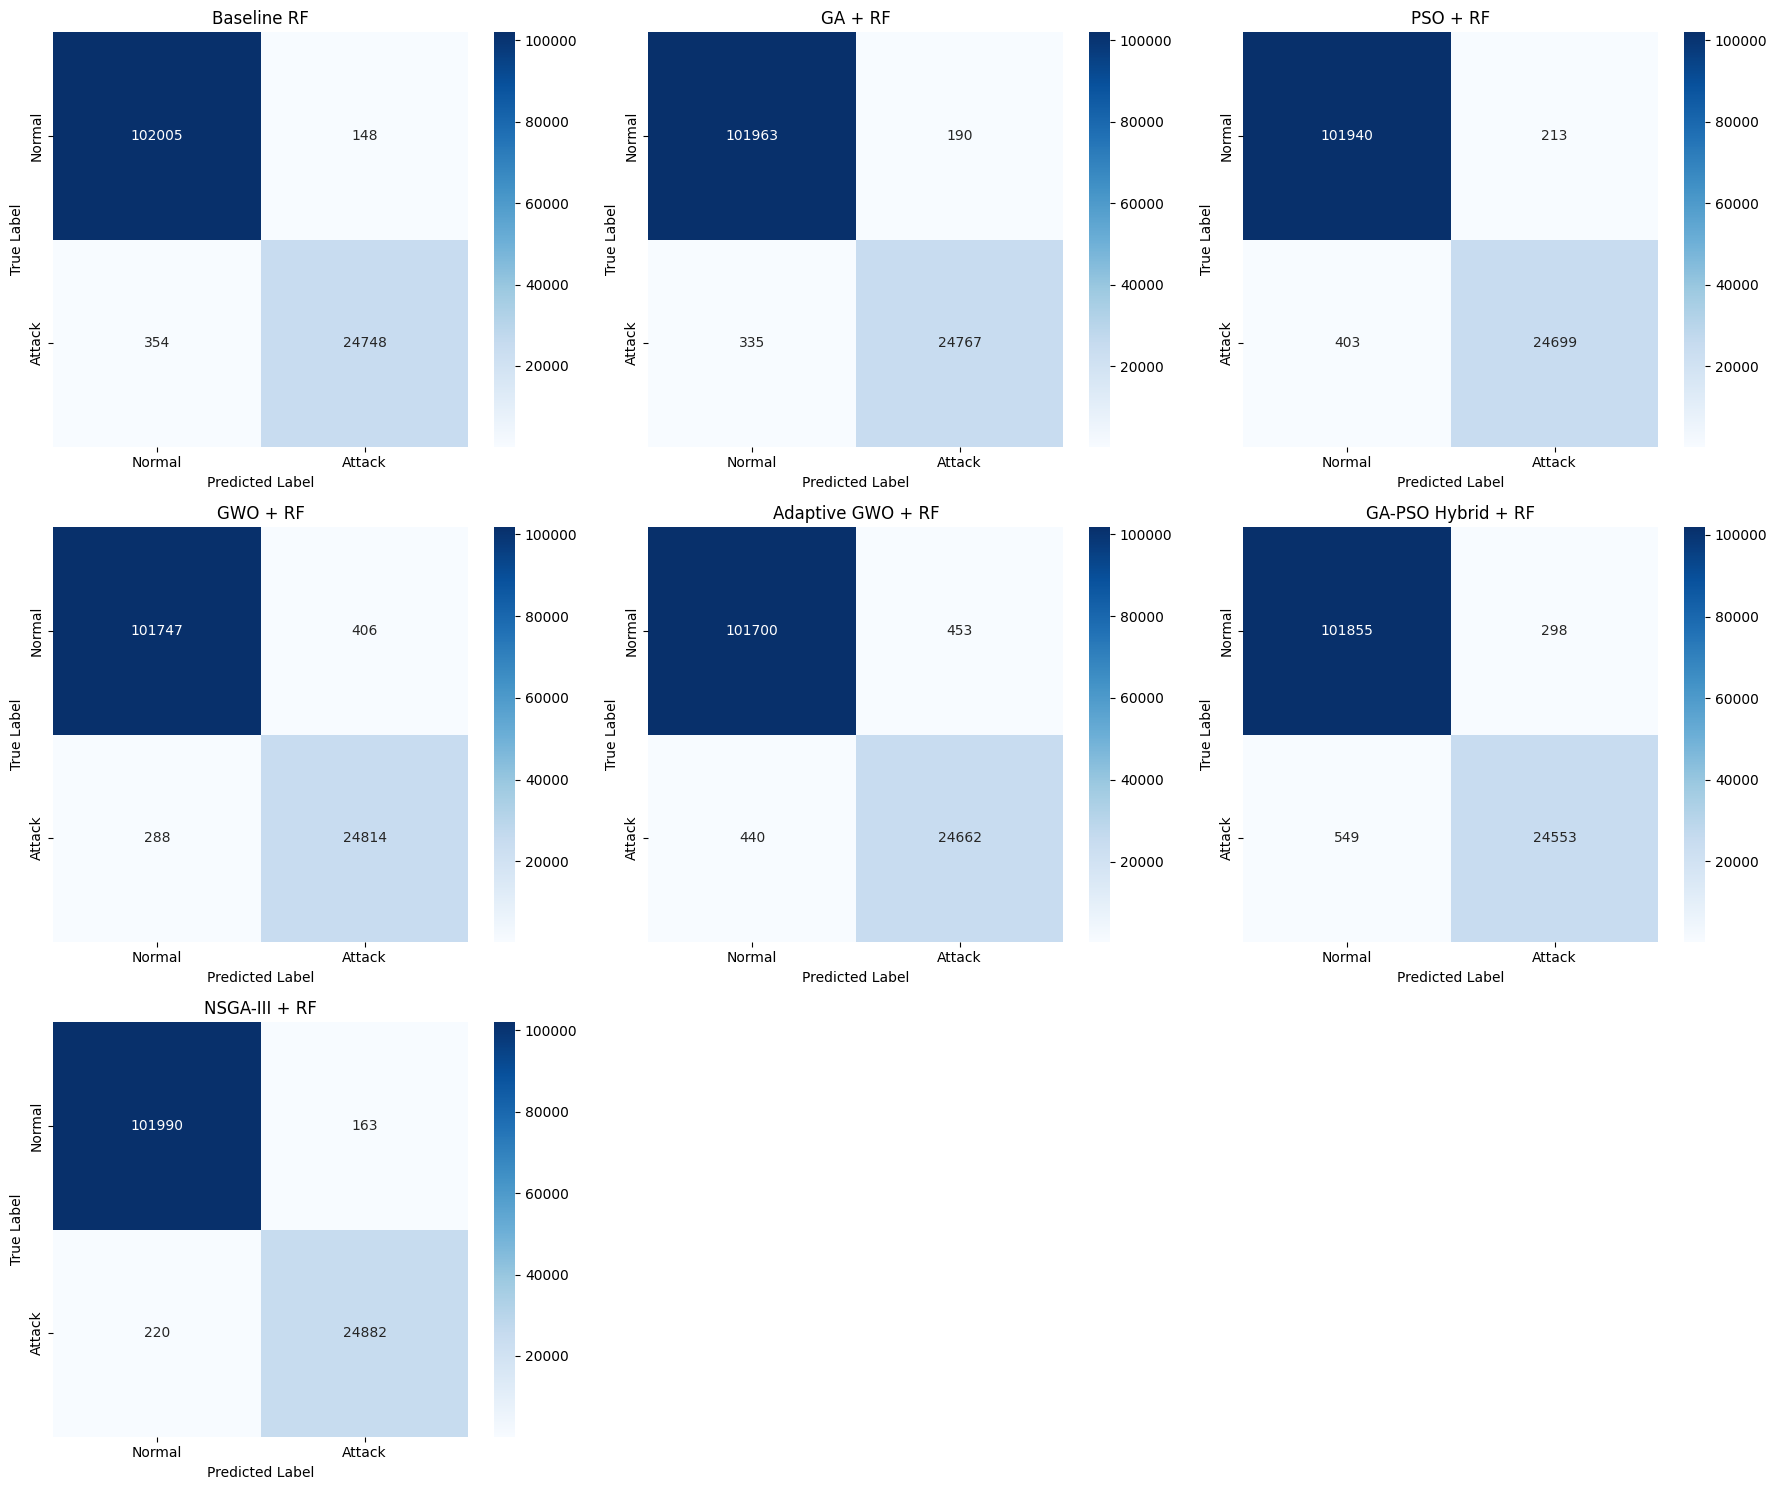

In [36]:
def plot_model_cm(ax, model, X_test_filtered, y_test, title):
    y_pred = model.predict(X_test_filtered)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"],
    )
    ax.set_title(title)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

model_specs = [
    ("Baseline RF", rf_baseline, X_test),
    ("GA + RF", rf_ga, X_test[:, ga_mask]),
    ("PSO + RF", rf_pso, X_test[:, pso_mask]),
    ("GWO + RF", rf_gwo, X_test[:, gwo_mask]),
    ("Adaptive GWO + RF", rf_agwo, X_test[:, agwo_mask]),
    ("GA-PSO Hybrid + RF", rf_gapso, X_test[:, gapso_mask]),
    ("NSGA-III + RF", rf_nsga3, X_test[:, nsga3_mask]),
]

n_models = len(model_specs)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (title, model, X_eval) in zip(axes, model_specs):
    plot_model_cm(ax, model, X_eval, y_test, title)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/confusion_matrices_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Grouped Bar Chart: Core Classification Metrics
Compare Accuracy, Precision, Recall, and F1 side by side to identify models that stay strong across all core metrics.

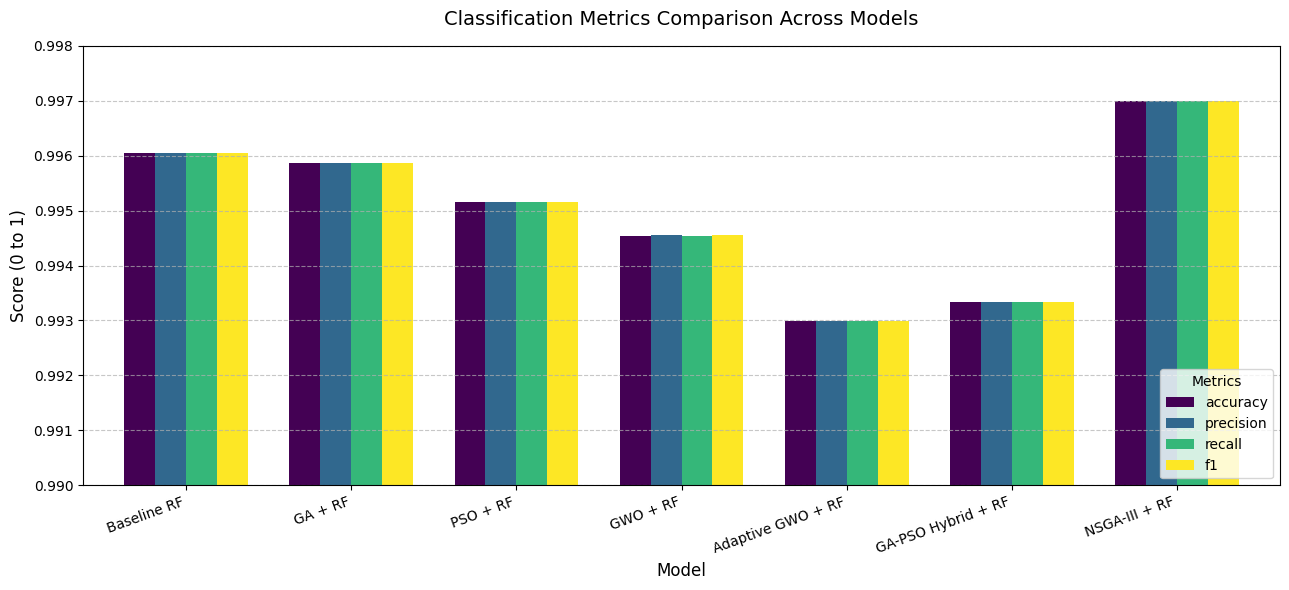

In [37]:
fig, ax = plt.subplots(figsize=(13, 6))
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    ax=ax,
    colormap="viridis",
    width=0.75,
)

plt.title("Classification Metrics Comparison Across Models", fontsize=14, pad=15)
plt.ylabel("Score (0 to 1)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right", title="Metrics")
plt.ylim(0.990, 0.998)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Feature Reduction vs. Accuracy (Scatter Plot)
Compare feature count against accuracy to check whether compact models keep performance close to full-feature models.

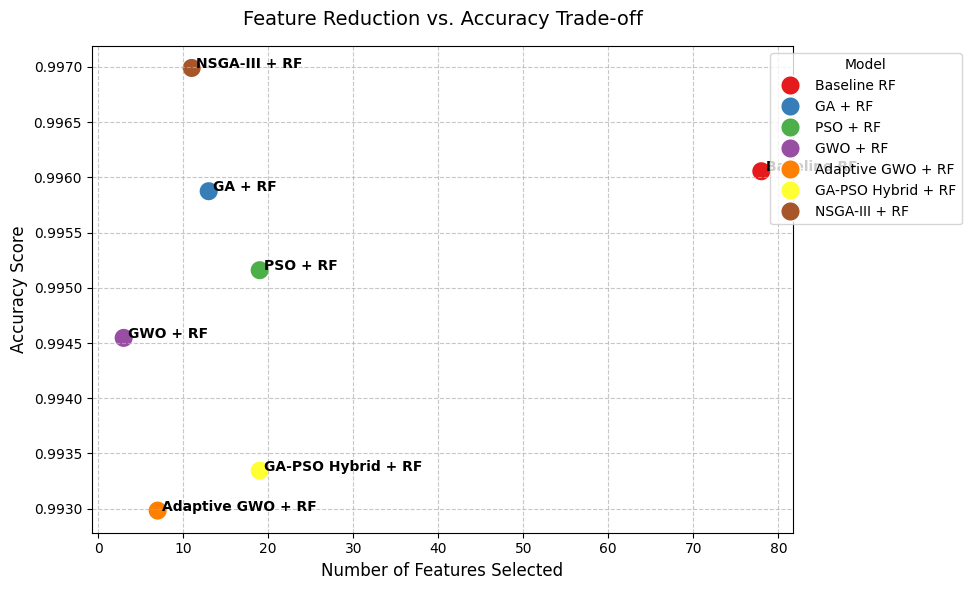

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot for feature count vs accuracy
sns.scatterplot(
    x='feature_count', y='accuracy', hue='Model', data=results_df, 
    s=200, marker='o', ax=ax, palette='Set1'
)

# Add annotations
for index, row in results_df.iterrows():
    ax.text(row.feature_count + 0.5, row.accuracy, row.Model, 
             horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title('Feature Reduction vs. Accuracy Trade-off', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Number of Features Selected', fontsize=12)

# Move legend outside
ax.legend(title='Model', loc='upper right', bbox_to_anchor=(1.25, 1))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/feature_vs_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. ROC Curves
Compare ROC curves to evaluate class-separation quality, especially how each model behaves at low false-positive rates.

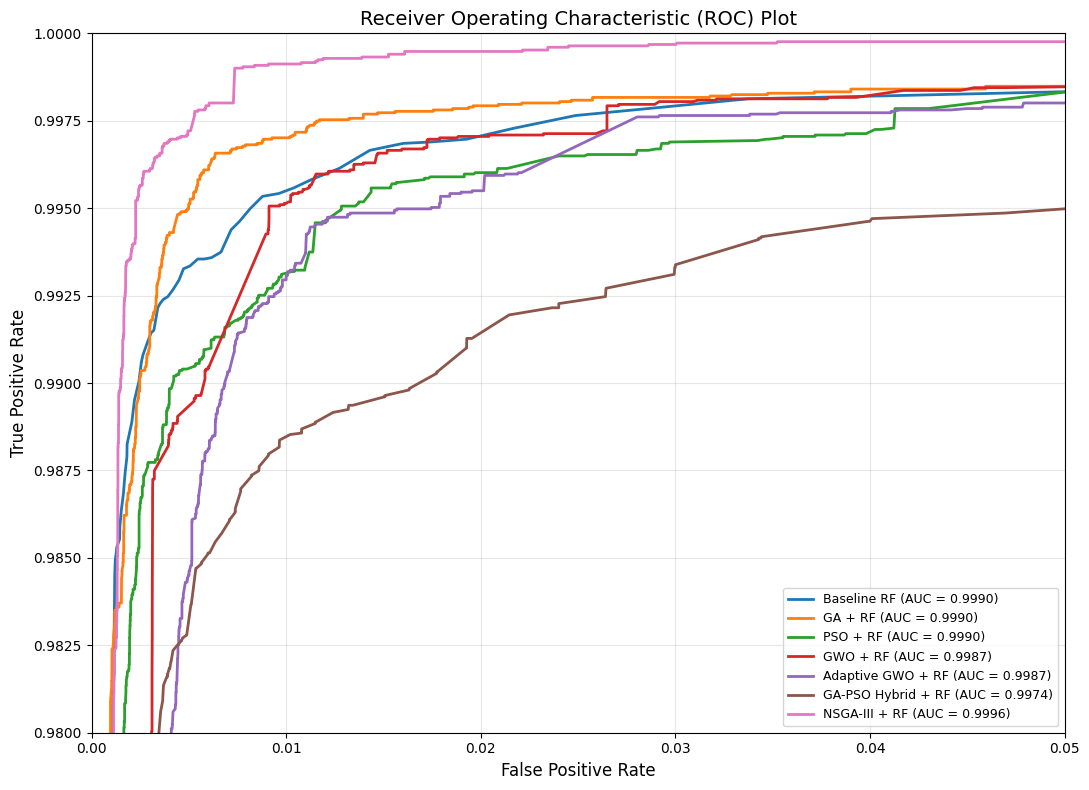

In [39]:
plt.figure(figsize=(11, 8))

model_specs = [
    ("Baseline RF", rf_baseline, X_test),
    ("GA + RF", rf_ga, X_test[:, ga_mask]),
    ("PSO + RF", rf_pso, X_test[:, pso_mask]),
    ("GWO + RF", rf_gwo, X_test[:, gwo_mask]),
    ("Adaptive GWO + RF", rf_agwo, X_test[:, agwo_mask]),
    ("GA-PSO Hybrid + RF", rf_gapso, X_test[:, gapso_mask]),
    ("NSGA-III + RF", rf_nsga3, X_test[:, nsga3_mask]),
]
colors = sns.color_palette("tab10", len(model_specs))

fpr_cap = 0.0

for (label, model, X_eval), color in zip(model_specs, colors):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.predict(X_eval).astype(float)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    fpr_cap = max(fpr_cap, float(np.max(fpr)))
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{label} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", alpha=0.7)

x_upper = max(0.004, min(0.05, fpr_cap * 1.05 + 1e-4))
plt.xlim([0.0, x_upper])
plt.ylim([0.98, 1.0])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Plot", fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.gcf().savefig("figures/roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Prediction Score Distribution (Benign vs Attack)
Compare score distributions for benign and attack traffic to judge how clearly each model separates the two classes at decision time.

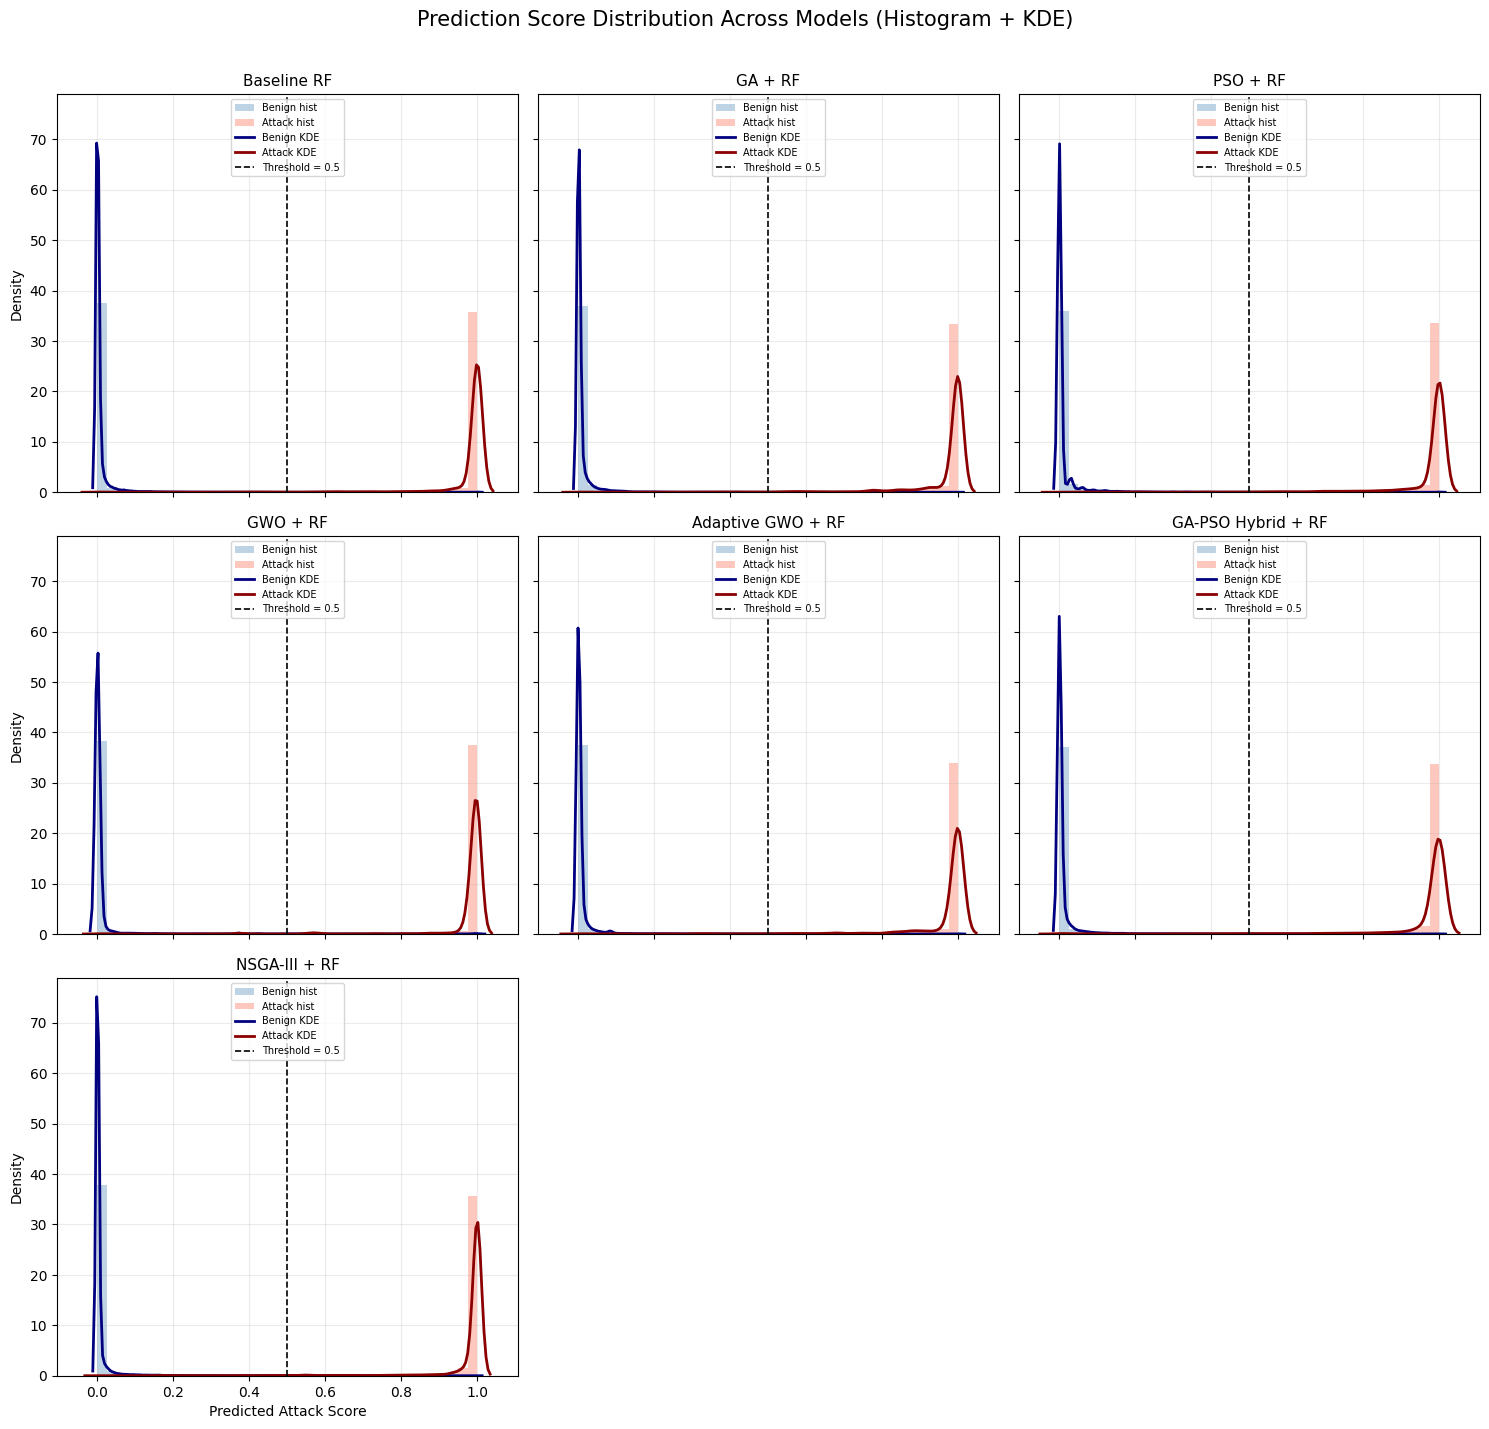

In [40]:
model_specs = [
    ("Baseline RF", rf_baseline, X_test),
    ("GA + RF", rf_ga, X_test[:, ga_mask]),
    ("PSO + RF", rf_pso, X_test[:, pso_mask]),
    ("GWO + RF", rf_gwo, X_test[:, gwo_mask]),
    ("Adaptive GWO + RF", rf_agwo, X_test[:, agwo_mask]),
    ("GA-PSO Hybrid + RF", rf_gapso, X_test[:, gapso_mask]),
    ("NSGA-III + RF", rf_nsga3, X_test[:, nsga3_mask]),
]

n_models = len(model_specs)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.7 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, (title, model, X_eval) in zip(axes, model_specs):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.predict(X_eval).astype(float)

    score_benign = y_score[np.array(y_test) == 0]
    score_attack = y_score[np.array(y_test) == 1]

    ax.hist(score_benign, bins=40, alpha=0.35, density=True, color="steelblue", label="Benign hist")
    ax.hist(score_attack, bins=40, alpha=0.35, density=True, color="tomato", label="Attack hist")

    sns.kdeplot(score_benign, ax=ax, color="navy", linewidth=2, label="Benign KDE")
    sns.kdeplot(score_attack, ax=ax, color="darkred", linewidth=2, label="Attack KDE")

    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Threshold = 0.5")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted Attack Score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper center")

for ax in axes[n_models:]:
    ax.axis("off")

plt.suptitle("Prediction Score Distribution Across Models (Histogram + KDE)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 11. False Positives Comparison
Compare false positives across models to identify which option minimizes alert noise and analyst workload.

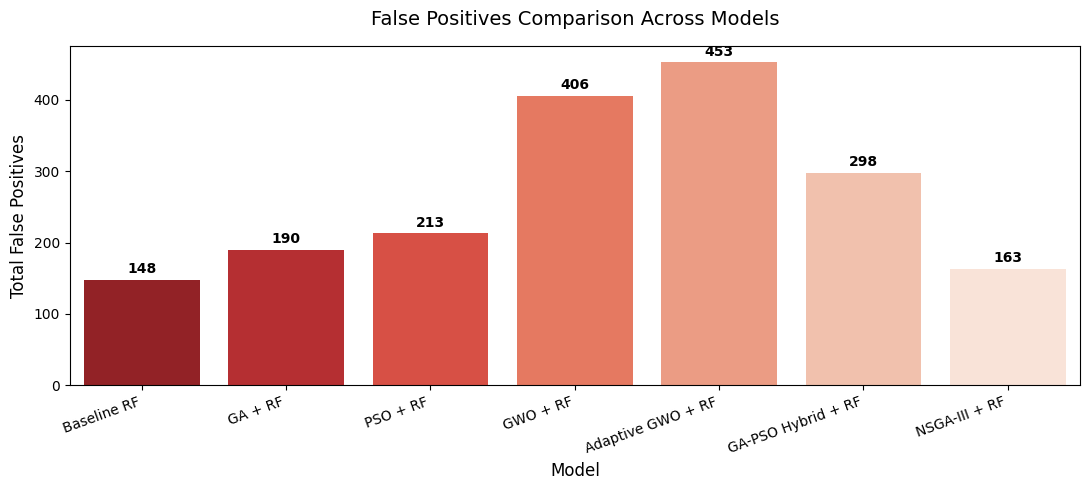

In [41]:
plt.figure(figsize=(11, 5))
ax = sns.barplot(x="Model", y="false_positives", data=results_df, palette="Reds_r")

plt.title("False Positives Comparison Across Models", fontsize=14, pad=15)
plt.ylabel("Total False Positives", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=20, ha="right")

for index, row in results_df.iterrows():
    offset = 0.02 * results_df["false_positives"].max() if results_df["false_positives"].max() > 0 else 1
    plt.text(
        index,
        row.false_positives + offset,
        int(row.false_positives),
        color="black",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.gcf().savefig("figures/false_positives_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. False Negatives (Missed Attacks) Comparison
Compare missed attacks across models to find safer choices for security-critical deployment.

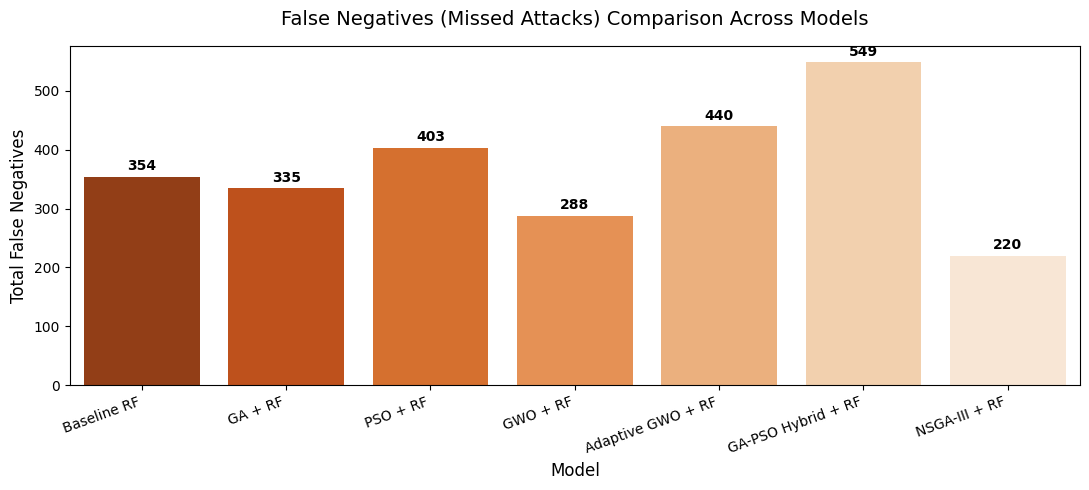

In [42]:
fn_data = []
for model, X_filtered, label in [
    (rf_baseline, X_test, "Baseline RF"),
    (rf_ga, X_test[:, ga_mask], "GA + RF"),
    (rf_pso, X_test[:, pso_mask], "PSO + RF"),
    (rf_gwo, X_test[:, gwo_mask], "GWO + RF"),
    (rf_agwo, X_test[:, agwo_mask], "Adaptive GWO + RF"),
    (rf_gapso, X_test[:, gapso_mask], "GA-PSO Hybrid + RF"),
    (rf_nsga3, X_test[:, nsga3_mask], "NSGA-III + RF"),
]:
    y_pred = model.predict(X_filtered)
    cm = confusion_matrix(y_test, y_pred)
    fn_data.append({"Model": label, "false_negatives": int(cm[1, 0])})

fn_df = pd.DataFrame(fn_data)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x="Model", y="false_negatives", data=fn_df, palette="Oranges_r")
plt.title("False Negatives (Missed Attacks) Comparison Across Models", fontsize=14, pad=15)
plt.ylabel("Total False Negatives", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=20, ha="right")

for index, row in fn_df.iterrows():
    offset = 0.02 * fn_df["false_negatives"].max() if fn_df["false_negatives"].max() > 0 else 1
    plt.text(
        index,
        row.false_negatives + offset,
        int(row.false_negatives),
        color="black",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.gcf().savefig("figures/false_negatives_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Attack Recall Comparison (Zoomed)
Use a zoomed recall comparison to highlight small but important differences in attack detection sensitivity.

,Model,attack_recall,miss_rate
0,Baseline RF,0.985898,0.014102
1,GA + RF,0.986654,0.013346
2,PSO + RF,0.983946,0.016054
3,GWO + RF,0.988527,0.011473
4,Adaptive GWO + RF,0.982472,0.017528
5,GA-PSO Hybrid + RF,0.978129,0.021871
6,NSGA-III + RF,0.991236,0.008764


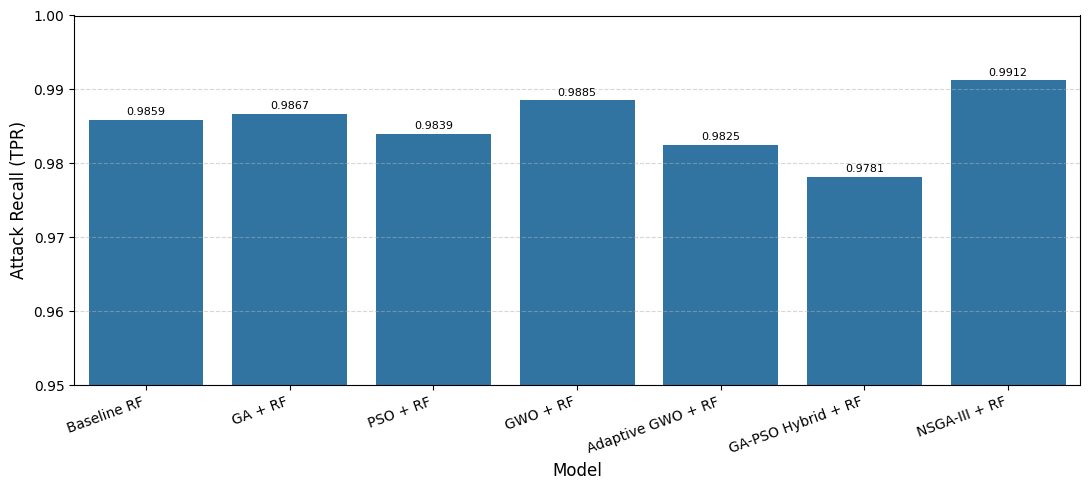

In [43]:
recall_rows = []
for model, X_filtered, label in [
    (rf_baseline, X_test, "Baseline RF"),
    (rf_ga, X_test[:, ga_mask], "GA + RF"),
    (rf_pso, X_test[:, pso_mask], "PSO + RF"),
    (rf_gwo, X_test[:, gwo_mask], "GWO + RF"),
    (rf_agwo, X_test[:, agwo_mask], "Adaptive GWO + RF"),
    (rf_gapso, X_test[:, gapso_mask], "GA-PSO Hybrid + RF"),
    (rf_nsga3, X_test[:, nsga3_mask], "NSGA-III + RF"),
]:
    y_pred = model.predict(X_filtered)
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        attack_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    else:
        attack_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    miss_rate = 1.0 - attack_recall
    recall_rows.append({
        "Model": label,
        "attack_recall": attack_recall,
        "miss_rate": miss_rate,
    })

recall_df = pd.DataFrame(recall_rows)
display(recall_df)

LOWER, UPPER = 0.950, 1.0000

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=recall_df, x="Model", y="attack_recall", color="#1f77b4")
ax.set_ylabel("Attack Recall (TPR)", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylim(LOWER, UPPER)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## 14. Training / Testing Execution Time
Compare train and test time to evaluate practical runtime cost and responsiveness across models.

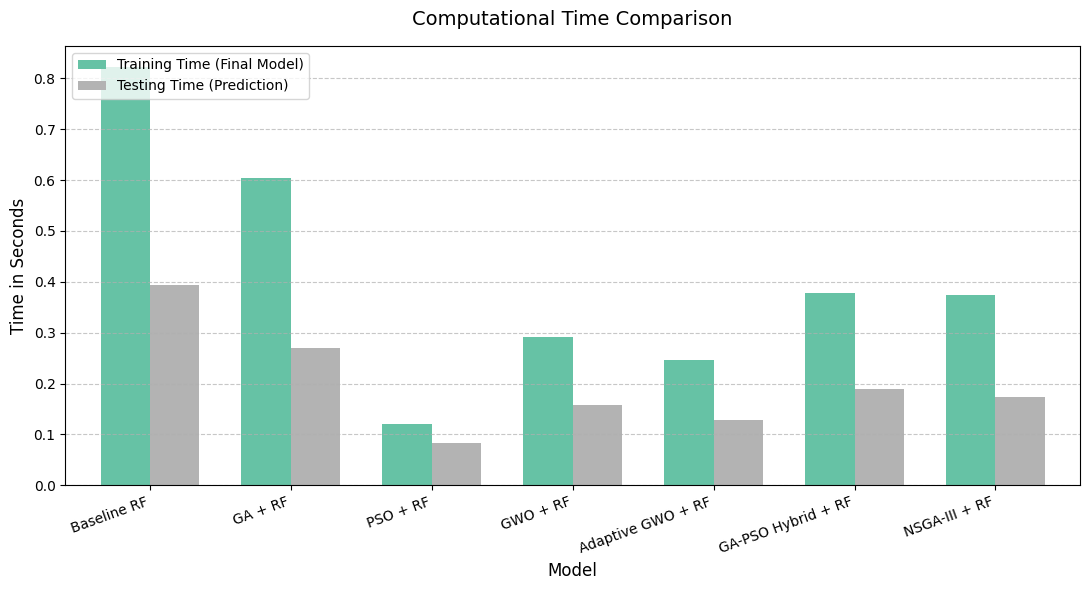

In [44]:
fig, ax = plt.subplots(figsize=(11, 6))

results_df.set_index("Model")[["train_time", "test_time"]].plot(
    kind="bar",
    ax=ax,
    colormap="Set2",
    width=0.7,
)

plt.title("Computational Time Comparison", fontsize=14, pad=15)
plt.ylabel("Time in Seconds", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=20, ha="right")
plt.legend(["Training Time (Final Model)", "Testing Time (Prediction)"], loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Performance Evolution Over Iterations (Disparity-Corrected)
Compare normalized convergence trends so optimizer progress is fair to read despite different raw objective scales.

Saved fitness-iteration screenshot to: artifacts/fitness_iteration_graph.png
Saved IEEE figure to: figures/fitness_iteration_graph.png


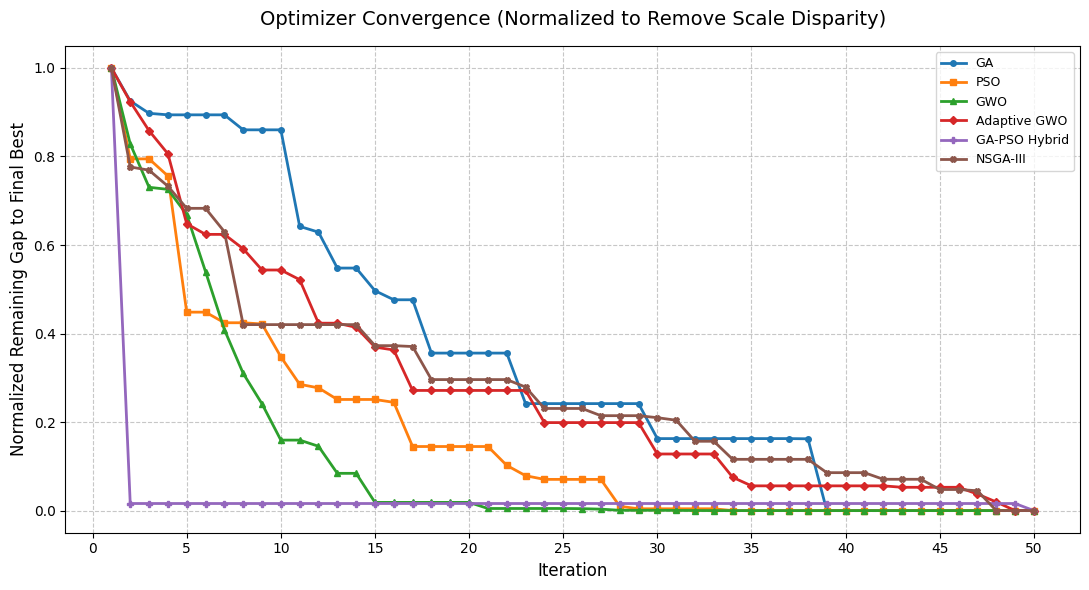

In [45]:
histories = {
    "GA": ga_history,
    "PSO": pso_history,
    "GWO": gwo_history,
    "Adaptive GWO": agwo_history,
    "GA-PSO Hybrid": gapso_history,
    "NSGA-III": nsga3_history,
}

normalized_histories = {}
for label, history in histories.items():
    arr = np.array(history, dtype=float)
    if len(arr) == 0:
        continue
    denom = arr[0] - arr[-1]
    if abs(denom) < 1e-12:
        norm = np.zeros_like(arr)
    else:
        # 1.0 at iteration 1, 0.0 at final iteration (for direct convergence-speed comparison).
        norm = (arr - arr[-1]) / denom
    normalized_histories[label] = np.clip(norm, -0.1, 1.1)

fig, ax = plt.subplots(figsize=(11, 6))
markers = ["o", "s", "^", "D", "P", "X"]
colors = sns.color_palette("tab10", len(normalized_histories))

for (label, norm_history), marker, color in zip(normalized_histories.items(), markers, colors):
    iterations = range(1, len(norm_history) + 1)
    ax.plot(
        iterations,
        norm_history,
        marker=marker,
        markersize=4,
        linewidth=2,
        label=label,
        color=color,
    )

max_len = max(len(h) for h in normalized_histories.values())
ax.set_title("Optimizer Convergence (Normalized to Remove Scale Disparity)", fontsize=14, pad=15)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Normalized Remaining Gap to Final Best", fontsize=12)
ax.set_xticks(np.arange(0, max_len + 1, 5))
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.7)

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)
screenshot_path = "artifacts/fitness_iteration_graph.png"
ieee_path = "figures/fitness_iteration_graph.png"
fig.savefig(screenshot_path, dpi=220, bbox_inches="tight")
fig.savefig(ieee_path, dpi=300, bbox_inches="tight")
print(f"Saved fitness-iteration screenshot to: {screenshot_path}")
print(f"Saved IEEE figure to: {ieee_path}")

plt.tight_layout()
plt.show()

## 16. Exact Feature Selection Comparison (Boolean Heatmap)
Compare selected and dropped features directly to understand each optimizer's selection pattern.

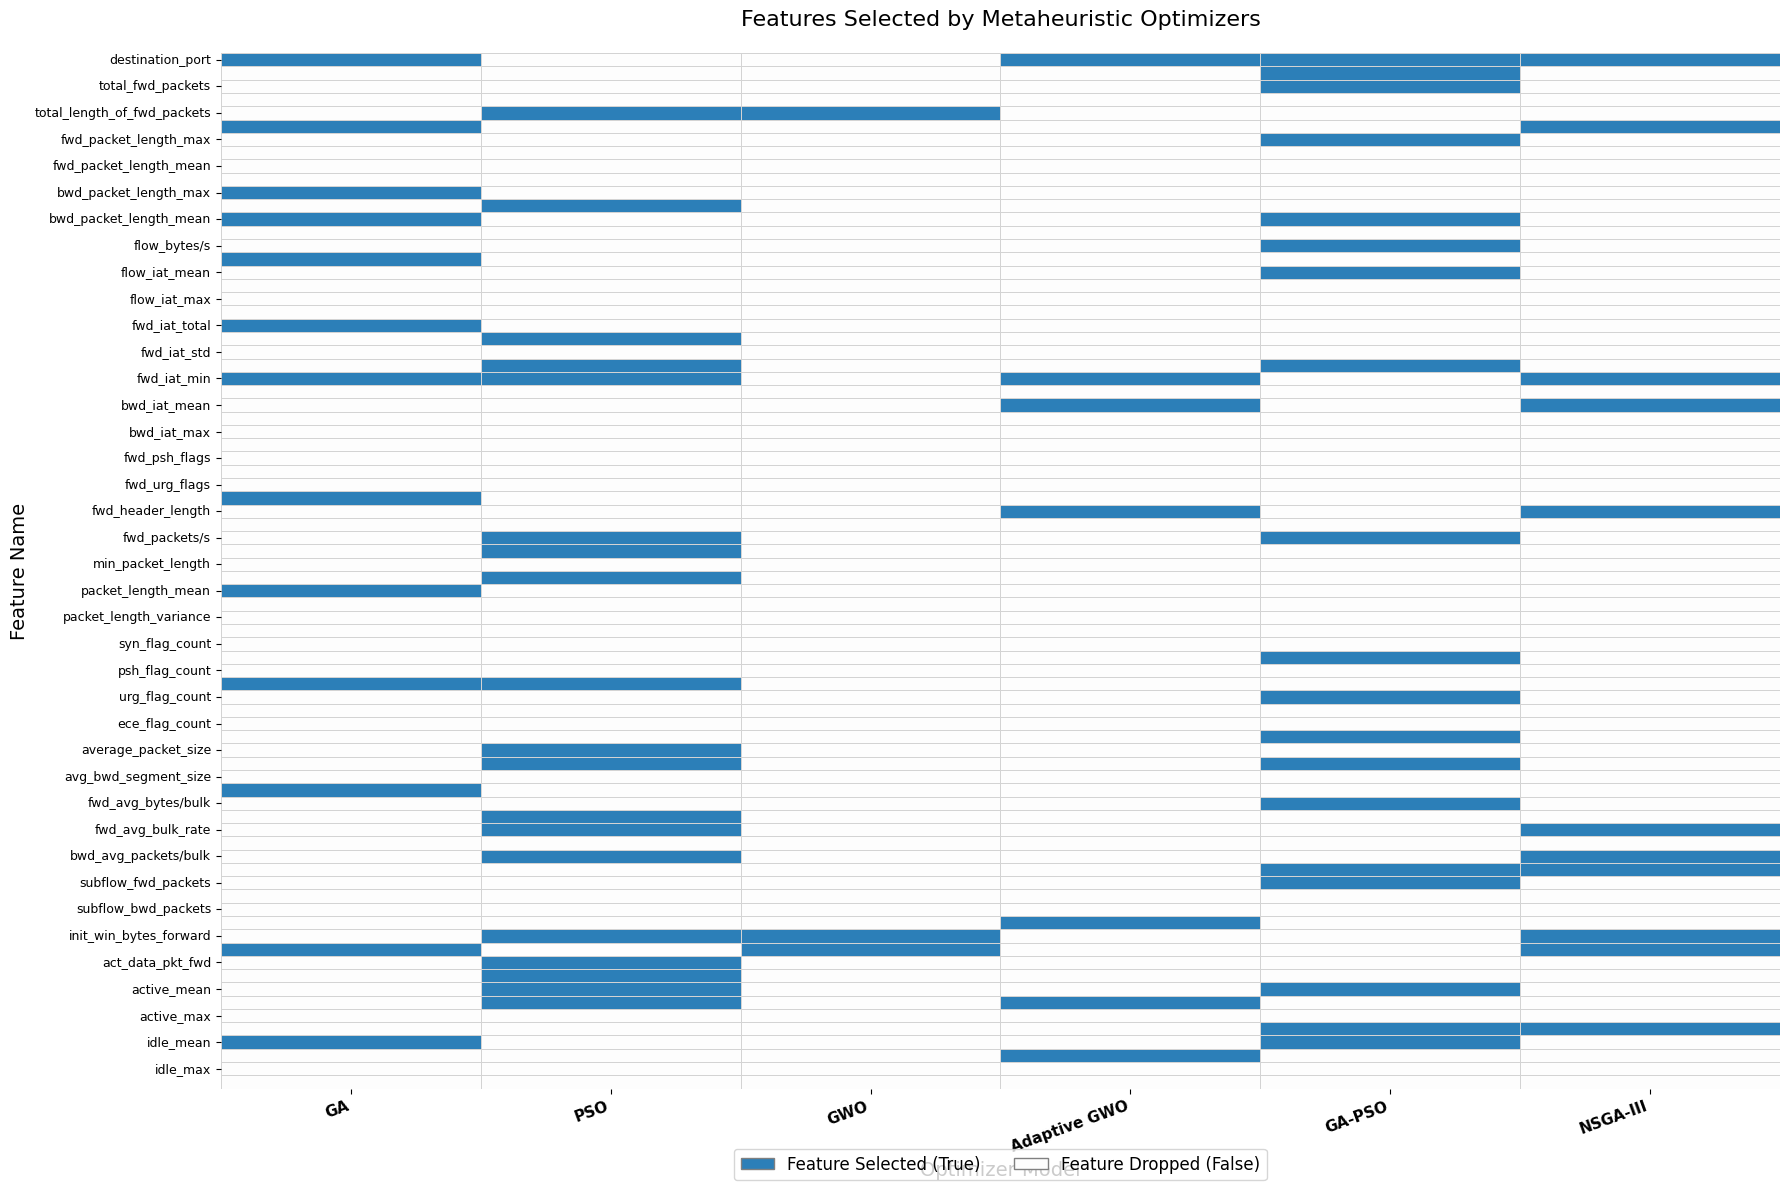

In [46]:
fig, ax = plt.subplots(figsize=(18, 12))

optimizer_masks = {
    "GA": ga_mask,
    "PSO": pso_mask,
    "GWO": gwo_mask,
    "Adaptive GWO": agwo_mask,
    "GA-PSO": gapso_mask,
    "NSGA-III": nsga3_mask,
}

num_feats = min([len(feature_names)] + [len(mask) for mask in optimizer_masks.values()])

mask_df = pd.DataFrame(
    {name: mask[:num_feats] for name, mask in optimizer_masks.items()},
    index=feature_names[:num_feats],
).astype(int)

sns.heatmap(
    mask_df,
    cmap=["#fdfdfd", "#2c7fb8"],
    linewidths=0.5,
    linecolor="lightgrey",
    cbar=False,
    ax=ax,
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#2c7fb8", edgecolor="gray", label="Feature Selected (True)"),
    Patch(facecolor="#fdfdfd", edgecolor="gray", label="Feature Dropped (False)"),
]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)

plt.title("Features Selected by Metaheuristic Optimizers", fontsize=16, pad=20)
plt.ylabel("Feature Name", fontsize=14)
plt.xlabel("Optimizer Model", fontsize=14)
plt.yticks(rotation=0, fontsize=9)
plt.xticks(fontsize=11, fontweight="bold", rotation=20, ha="right")

plt.tight_layout()
plt.show()

## 17. Feature Importances Within Selected Subsets
Compare feature importances within each selected subset to see which chosen features actually drive predictions.

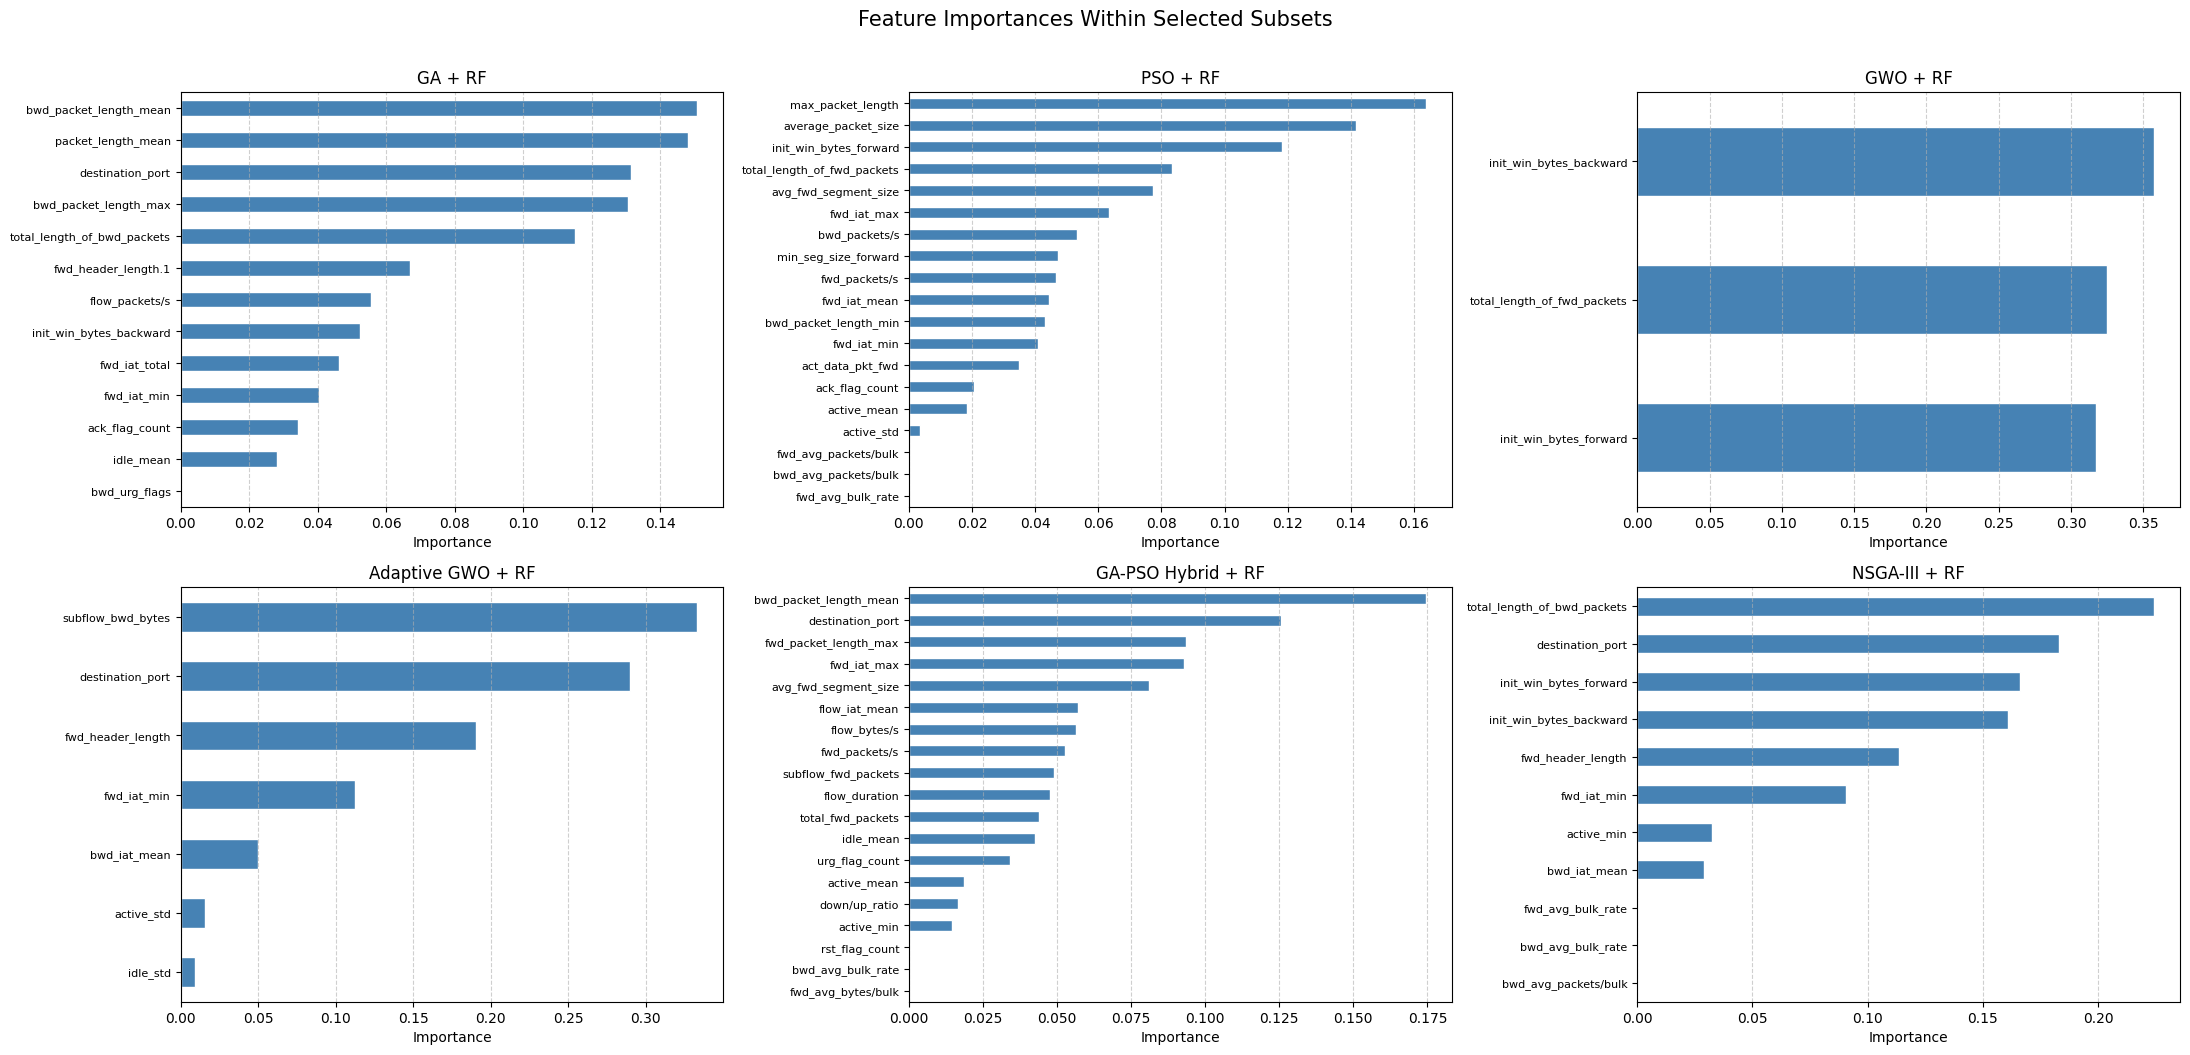

In [47]:
feature_models = [
    (rf_ga, ga_mask, "GA + RF"),
    (rf_pso, pso_mask, "PSO + RF"),
    (rf_gwo, gwo_mask, "GWO + RF"),
    (rf_agwo, agwo_mask, "Adaptive GWO + RF"),
    (rf_gapso, gapso_mask, "GA-PSO Hybrid + RF"),
    (rf_nsga3, nsga3_mask, "NSGA-III + RF"),
]

n_models = len(feature_models)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.2 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, (model, mask, title) in zip(axes, feature_models):
    selected_names = [
        feature_names[i]
        for i in range(min(len(feature_names), len(mask)))
        if mask[i]
    ]
    importances = np.array(model.feature_importances_)

    usable = min(len(selected_names), len(importances))
    if usable == 0:
        ax.text(0.5, 0.5, "No selected features", ha="center", va="center")
        ax.set_title(title, fontsize=12)
        ax.axis("off")
        continue

    imp_series = pd.Series(
        importances[:usable],
        index=selected_names[:usable],
    ).sort_values(ascending=True)
    imp_series.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Importance", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.6)

for ax in axes[n_models:]:
    ax.axis("off")

plt.suptitle("Feature Importances Within Selected Subsets", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 18. Feature Selection Overlap - Jaccard Similarity
Compare overlap in selected features to see whether optimizers agree on informative dimensions or diverge.

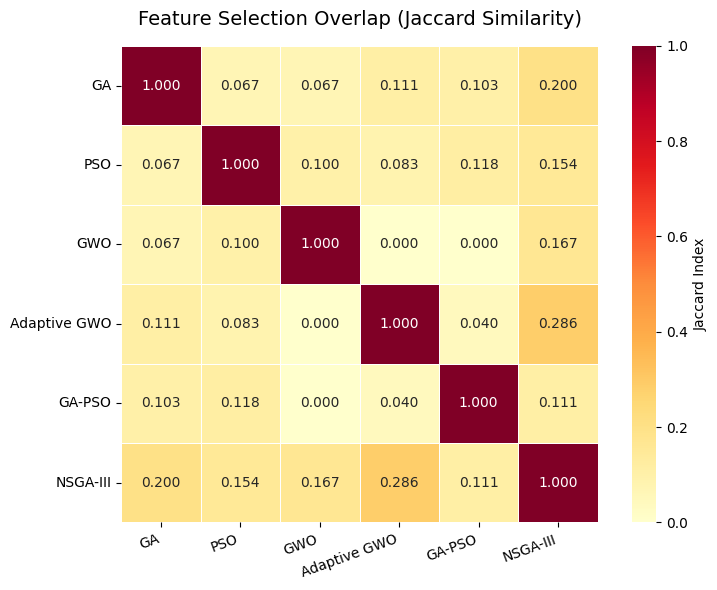

In [48]:
optimizer_masks = {
    "GA": ga_mask,
    "PSO": pso_mask,
    "GWO": gwo_mask,
    "Adaptive GWO": agwo_mask,
    "GA-PSO": gapso_mask,
    "NSGA-III": nsga3_mask,
}
opt_names = list(optimizer_masks.keys())

jaccard_matrix = pd.DataFrame(index=opt_names, columns=opt_names, dtype=float)

for a in opt_names:
    for b in opt_names:
        set_a = set(np.where(optimizer_masks[a])[0])
        set_b = set(np.where(optimizer_masks[b])[0])
        intersection = len(set_a & set_b)
        union = len(set_a | set_b)
        jaccard_matrix.loc[a, b] = intersection / union if union > 0 else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={"label": "Jaccard Index"},
)
plt.title("Feature Selection Overlap (Jaccard Similarity)", fontsize=14, pad=15)
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Model Performance Radar Chart
Compare models across multiple metrics at once to judge overall balance rather than a single best score.

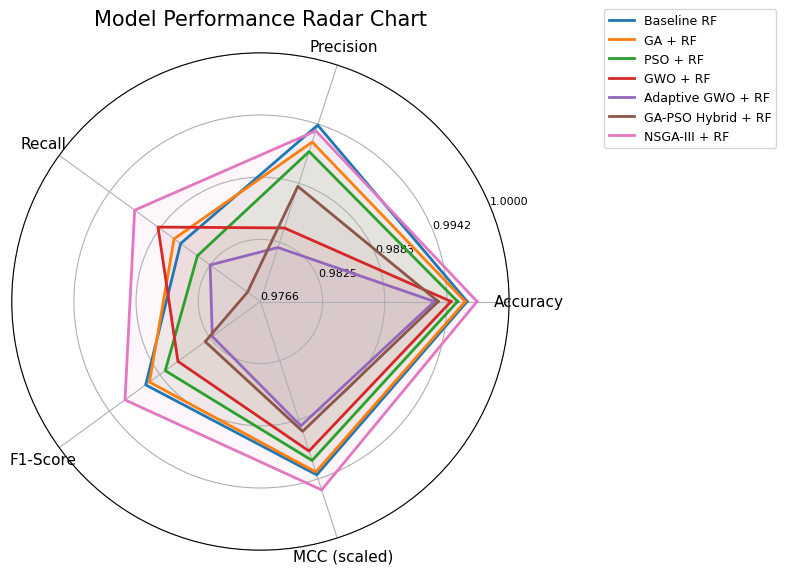

In [49]:
def get_radar_metrics(model, X_filtered, y_true):
    y_pred = model.predict(X_filtered)
    mcc = matthews_corrcoef(y_true, y_pred)
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        (mcc + 1) / 2,
    ]

categories = ["Accuracy", "Precision", "Recall", "F1-Score", "MCC (scaled)"]
num_axes = len(categories)
angles = [n / float(num_axes) * 2 * np.pi for n in range(num_axes)]
angles += angles[:1]

model_specs = [
    ("Baseline RF", rf_baseline, X_test),
    ("GA + RF", rf_ga, X_test[:, ga_mask]),
    ("PSO + RF", rf_pso, X_test[:, pso_mask]),
    ("GWO + RF", rf_gwo, X_test[:, gwo_mask]),
    ("Adaptive GWO + RF", rf_agwo, X_test[:, agwo_mask]),
    ("GA-PSO Hybrid + RF", rf_gapso, X_test[:, gapso_mask]),
    ("NSGA-III + RF", rf_nsga3, X_test[:, nsga3_mask]),
]

model_data = {
    label: get_radar_metrics(model, X_eval, y_test)
    for label, model, X_eval in model_specs
}

colors = sns.color_palette("tab10", len(model_data))

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for (label, values), color in zip(model_data.items(), colors):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, linewidth=2, linestyle="solid", label=label, color=color)
    ax.fill(angles, values_plot, alpha=0.06, color=color)

data_min = min(min(values) for values in model_data.values())
target_min = 0.9998
radial_min = target_min if data_min >= target_min else max(0.95, data_min - 0.0015)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(radial_min, 1.0)
if radial_min >= target_min:
    ax.set_yticks([0.9998, 0.9999, 1.0])
    ax.set_yticklabels(["0.9998", "0.9999", "1.0000"], fontsize=8)
else:
    yticks = np.linspace(radial_min, 1.0, 5)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{tick:.4f}" for tick in yticks], fontsize=8)

ax.set_title("Model Performance Radar Chart", fontsize=15, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.55, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

## 20. Conference Paper Template Mapping
Quick checklist for writing the final conference paper.

1. Introduction: IDS problem context, motivation, and contributions.
2. Related Work: 10-year review with emphasis on recent 5 years, including surveys/reviews.
3. Methodology: dataset, preprocessing, baseline RF, GA/PSO/GWO search space, objective function.
4. Experimental Setup: train/test split, subset size strategy, optimizer settings, reproducibility choices.
5. Results: baseline vs optimized models in metrics table and all key plots.
6. Discussion: trade-offs between accuracy, false positives, feature reduction, and compute cost.
7. Conclusion and Future Work: practical implications and planned extensions.

Suggested figure/table mapping from this notebook:
- Metrics table: `results_df`.
- Confusion matrices: Section 6.
- ROC and prediction-score distribution: Sections 9 and 10.
- False positives/negatives and runtime bars: Sections 11, 12, and 14.
- Feature analyses: Sections 16, 17, and 18.
- Optimizer convergence: Section 15 (performance evolution).

## 21. Final Results Summary

> This section consolidates the practical decision from the full optimizer comparison in this run.

Across all seven variants, **NSGA-III + RF** provides the strongest overall balance of IDS quality. It achieves the best combined detection profile with top accuracy and recall, and the lowest missed-attack tendency among the compared approaches. This makes it the most suitable default choice when balanced cyber-risk reduction is the primary objective.

**Baseline RF** remains highly competitive and is still the best low-alert option in this run because it produces the fewest false positives. If reducing analyst fatigue is the main operational priority, Baseline RF remains an excellent deployment baseline.

For deployment scenarios with strict compute and memory limits, the **GWO-family methods** are especially valuable. GWO, Adaptive GWO, and GA-PSO Hybrid preserve strong performance while delivering major feature-count reduction, indicating clear potential for lightweight IDS configurations.

Runtime analysis also favors swarm/hybrid approaches for efficient execution once compact configurations are found. Combined with feature compression, this supports their use in resource-constrained environments where inference speed and model footprint matter.

A key reporting correction was addressed by replacing raw-cost convergence comparison with a normalized convergence view. Because optimizers operate on different objective scales, normalization is required for fair cross-optimizer interpretation of stability and progress.

**Recommendation from this experiment:**
1. Use **NSGA-III + RF** as the primary balanced-performance model.
2. Keep **Baseline RF** as the low-false-positive operational benchmark.
3. Prefer **GWO-family variants** when aggressive feature compression is a hard deployment constraint.

This final comparison indicates that optimizer choice should be driven by deployment objective: balanced threat capture, alert-volume control, or compactness under resource limits.

## 22. Export Figures for IEEE Paper
Use the helper module to export currently open matplotlib figures to the exact filenames expected by `main.tex`.

In [50]:
from export_figures_helper import print_open_figures, export_open_figures

# 1) Inspect current open figures after running all plotting cells.
print_open_figures()

# 2) Update figure numbers if your order differs.
fig_map = {
    1: "confusion_matrices_all_models.png",
    2: "roc_comparison.png",
    3: "false_positives_comparison.png",
    4: "false_negatives_comparison.png",
    5: "runtime_comparison.png",
    6: "feature_vs_accuracy.png",
}

# 3) Export to the folder used by main.tex (via \graphicspath).
export_open_figures(fig_map, out_dir="figures", dpi=300)

print("Done. Check the figures/ folder and update fig_map numbers if needed.")

No open matplotlib figures found.
\nExpected LaTeX figure filenames:
- pipeline_overview.png: MISSING
- confusion_matrices_all_models.png: OK
- roc_comparison.png: OK
- false_positives_comparison.png: OK
- false_negatives_comparison.png: OK
- runtime_comparison.png: OK
- feature_vs_accuracy.png: OK
- fitness_iteration_graph.png: OK
Done. Check the figures/ folder and update fig_map numbers if needed.
